# Boosting and Stacking - Introduction

While Bagging focuses on reducing variance (overfitting) by averaging independent models, Boosting and Stacking attack the problem from completely different architectural angles.

Here is your brief introduction and direct comparison guide.

1. **Boosting: The Team of Specialists**

    If Bagging is like a democratic committee where everyone votes independently, Boosting is like a relay race where each runner fixes the mistakes of the previous one.

    * How it works: Boosting trains models sequentially (one after the other), rather than in parallel. It starts with an incredibly simple base model (often a single decision split or "stump"). It evaluates the errors that model made, gives extra mathematical weight to the misclassified rows, and forces the next tree to focus entirely on fixing those specific mistakes.

    * The Key Goal: Boosting focuses on reducing bias (underfitting). It turns a collection of weak, simple models into a single, highly accurate powerhouse.

    * Famous Algorithms: AdaBoost, Gradient Boosting, XGBoost, and LightGBM.

    <BR>

2. **Stacking: The Council of Experts**

    Stacking (Stacked Generalization) introduces an entirely different concept: instead of training a crowd of the same algorithm family (like dozens of trees), it trains a diverse group of completely different algorithm types and uses a final model to aggregate their predictions.

    * How it works: You train a heterogeneous mix of base models—for example, a Logistic Regression, a Random Forest, a KNN, and an SVM—all on your dataset. Then, instead of just taking a simple average of their votes, you feed their individual predictions as new features into a final "Meta-Model" (usually a simple Logistic Regression or Linear Regression). The Meta-Model learns which expert to trust for which specific types of data rows.

    * The Key Goal: Maximizing sheer predictive power by blending entirely different mathematical perspectives.

<BR>

### **The Ultimate Comparison Matrix**

|Characteristic|"Bagging (e.g., BaggingClassifier)"|Random Forest|"Boosting (e.g., XGBoost, Gradient Boosting)"|Stacking (Stacked Generalization)|
|---|---|---|---|---|
|Model Structure|Parallel; Independent trees/estimators.|Parallel; Independent trees with feature randomization.|Sequential; Each tree corrects the prior tree's errors.|Layered; Base models feed their outputs into a meta-model.|
|Base Estimator Types|"Can be anything (KNN, Trees, Linear)."|Strictly Decision Trees.|"Almost always shallow Decision Trees (""stumps"")."|"Diverse mixture (e.g., KNN + SVM + Trees together)."|
|Primary Mathematical Target|Reduces Variance (stops overfitting).|Reduces Variance even better than standard Bagging.|Reduces Bias (converts weak models into strong ones).|Maximizes overall performance by combining algorithmic strengths.|
|Risk of Overfitting|Very low; adding more trees never hurts.|Very low; highly robust out-of-the-box.|"High; if you add too many sequential steps, it will memorize noise."|Moderate to High; requires strict cross-validation to prevent leakage.|
|How Predictions are Combined|Simple voting or averaging.|Simple voting or averaging.|Weighted sum of all sequential tree outputs.|A final meta-algorithm learns how to weight the outputs.|


While Boosting is usually used with a variety of Decision Trees in practice, it however, can technically use other algorithms too. The only requirement for Boosting is that the base algorithm must be a "Weak Learner" - a model that is computationally fast and performs just slightly better than random guessing. Decision Trees are commonly chosen because they are very fast to build sequentially, can naturally handle non-linear relationships, and their complexity can be easily capped via its depth.

Think of the difference like this:

* Boosting is a process of evolution. It takes one specific species of model (almost always a shallow decision tree) and breeds it sequentially, generation after generation, forcing each new generation to adapt and fix the genetic flaws of the parents.

* Stacking is a panel of experts. It gathers entirely different species of models into a single room, lets them all look at the same problem, and uses a manager (the meta-model) to decide whose answer to trust.

<BR><BR>

___

<BR>


## Boosting and Stacking - Demo Lab

Estimated time needed: **45** minutes

## Objectives

After completing this demo you will be able to:

*   Understand how Gradient Boosting helps reduce error
*   Identify the benefits of using AdaBoost
*   Interpret the benefits of stacking models and comparing their results to boosted models


## Introduction

We will be using the [Human Activity Recognition with Smartphones](https://archive.ics.uci.edu/ml/datasets/Human+Activity+Recognition+Using+Smartphones?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML241ENSkillsNetwork31576874-2022-01-01) database, which was built from the recordings of study participants performing activities of daily living (ADL) while carrying a smartphone with an embedded inertial sensors. The objective is to classify activities into one of the six activities (walking, walking upstairs, walking downstairs, sitting, standing, and laying) performed.

For each record in the dataset it is provided:

*   Triaxial acceleration from the accelerometer (total acceleration) and the estimated body acceleration.
*   Triaxial angular velocity from the gyroscope.
*   A 561-feature vector with time and frequency domain variables.
*   Its activity label.

More information about the features is available on the website shown above.


In [1]:
import seaborn as sns, pandas as pd, numpy as np

<h2 id="Q1">Question 1</h2>

*   Import the data from the file `Human_Activity_Recognition_Using_Smartphones_Data.csv` and examine the shape and data types. For the data types, there will be too many to list each column separately. Rather, aggregate the types by count.
*   Determine if the float columns need to be scaled.


In [2]:
# data_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML241EN-SkillsNetwork/labs/datasets/Human_Activity_Recognition_Using_Smartphones_Data.csv"

data = pd.read_csv("data/Human_Activity_Recognition_Using_Smartphones_Data.csv", sep=',')

The data has quite a few predictor columns.


In [3]:
data.shape

(10299, 562)

And they're all float values. The only non-float is the categories column, which is being predicted.


In [4]:
data.dtypes.value_counts()

float64    561
str          1
Name: count, dtype: int64

The minimum and maximum value for the float columns is -1.0 and 1.0, respectively. However, scaling is never required for tree-based methods.


In [5]:
# Mask to select float columns
float_columns = (data.dtypes == float)

# Verify that the maximum of all float columns is 1.0
print( (data.loc[:,float_columns].max()==1.0).all() )

# Verify that the minimum of all float columns is -1.0
print( (data.loc[:,float_columns].min()==-1.0).all() )
### END SOLUTION

True
True


<h2 id="Q2">Question 2</h2>

*   Integer encode the activities.
*   Split the data into train and test data sets. Decide if the data will be stratified or not during the train/test split.


In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

data['Activity'] = le.fit_transform(data['Activity'])

le.classes_

array(['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS',
       'WALKING_UPSTAIRS'], dtype=object)

In [7]:
data.Activity.unique()

array([2, 1, 0, 3, 4, 5])

**NOTE**: We are about to create training and test sets from `data`. On those datasets, we are going to run grid searches over many choices of parameters. This can take some time. In order to shorten the grid search time, feel free to downsample `data` and create `X_train, X_test, y_train, y_test` from the downsampled dataset.

Now split the data into train and test data sets. A stratified split was not used here. If there are issues with any of the error metrics on the test set, it can be a good idea to start model fitting over using a stratified split. Boosting is a pretty powerful model, though, so it may not be necessary in this case.


In [8]:
from sklearn.model_selection import train_test_split

# Alternatively, we could stratify the categories in the split, as was done previously
feature_columns = [x for x in data.columns if x != 'Activity']

X_train, X_test, y_train, y_test = train_test_split(data[feature_columns], data['Activity'],
                 test_size=0.3, random_state=42)


In [9]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape


((7209, 561), (7209,), (3090, 561), (3090,))

<h2 id="Q3">Question 3</h2>

*   Fit gradient boosted tree models with all parameters set to their defaults with the following tree numbers (`n_estimators = [15, 25, 50, 100, 200, 400]`) and evaluate the accuracy on the test data for each of these models.
*   Plot the accuracy as a function of estimator number.

*Note:* there is no out-of-bag error for boosted models. And the `warm_flag=True` setting has a bug in the gradient boosted model, so don't use it. Simply create the model inside the `for` loop and set the number of estimators at this time. This will make the fitting take a little longer. Additionally, boosting models tend to take longer to fit than bagged ones because the decision stumps must be fit successively.


In [10]:
# from sklearn.ensemble import GradientBoostingClassifier
# from sklearn.metrics import accuracy_score

# error_list = list()

# # Iterate through various possibilities for number of trees
# tree_list = [15, 25, 50, 100, 200, 400]
# for n_trees in tree_list:
    
#     # Initialize the gradient boost classifier
#     GBC = GradientBoostingClassifier(n_estimators=n_trees, random_state=42)

#     # Fit the model
#     print(f'Fitting model with {n_trees} trees')
#     GBC.fit(X_train, y_train)
#     y_pred = GBC.predict(X_test)

#     # Get the error
#     error = 1.0 - accuracy_score(y_test, y_pred)
    
#     # Store it
#     error_list.append(pd.Series({'n_trees': n_trees, 'error': error}))

# error_df = pd.concat(error_list, axis=1).T.set_index('n_trees')

# error_df

In [11]:
import os
import joblib
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# Define a file name to save your calculated errors
CACHE_FILENAME = "gbc_error_results.pkl"
tree_list = [15, 25, 50, 100, 200, 400]

if os.path.exists(CACHE_FILENAME):
    print("--> Found cached results! Loading your error DataFrame instantly...")
    error_df = joblib.load(CACHE_FILENAME)
else:
    print("--> No cache found. Running the tree iterations (this will take a moment)...")
    error_list = list()

    # Iterate through various possibilities for number of trees
    for n_trees in tree_list:
        
        # Initialize the gradient boost classifier
        GBC = GradientBoostingClassifier(n_estimators=n_trees, random_state=42)

        # Fit the model
        print(f'Fitting model with {n_trees} trees')
        GBC.fit(X_train, y_train)
        y_pred = GBC.predict(X_test)

        # Get the error
        error = 1.0 - accuracy_score(y_test, y_pred)
        
        # Store it
        error_list.append(pd.Series({'n_trees': n_trees, 'error': error}))

    error_df = pd.concat(error_list, axis=1).T.set_index('n_trees')
    
    # Save the final dataframe so you don't have to retrain next time
    joblib.dump(error_df, CACHE_FILENAME)
    print("--> Iterations complete! Results saved to disk.")

# Always display the final error dataframe at the end
error_df

--> Found cached results! Loading your error DataFrame instantly...


,error
n_trees,
15.0,0.051133
25.0,0.033981
50.0,0.019741
100.0,0.013592
200.0,0.011003
400.0,0.010032


Now plot the result.


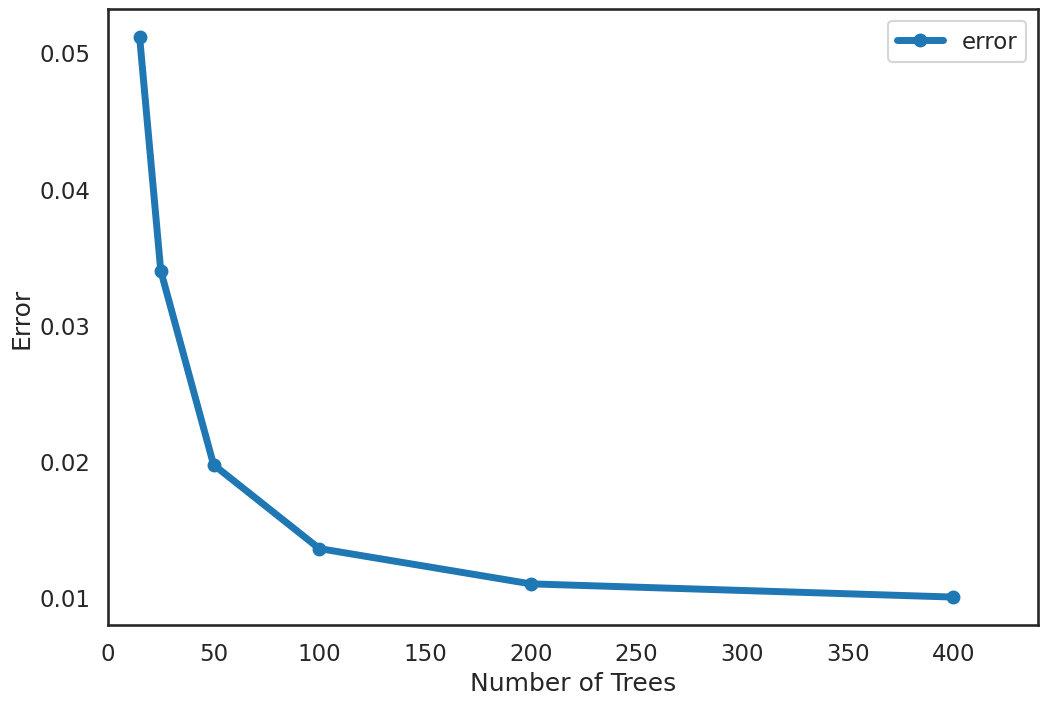

In [12]:
sns.set_context('talk')
sns.set_style('white')

# Create the plot
ax = error_df.plot(marker='o', figsize=(12, 8), linewidth=5)

# Set parameters
ax.set(xlabel='Number of Trees', ylabel='Error')
ax.set_xlim(0, max(error_df.index)*1.1);
### END SOLUTION

<h2 id="Q4">Question 4</h2>

*   Using a grid search with cross-validation, fit a new gradient boosted classifier with the same list of estimators as question 3. Also try varying the learning rates (0.1, 0.01, 0.001, etc.), the subsampling value (1.0 or 0.5), and the number of maximum features (1, 2, etc.).
*   Examine the parameters of the best fit model.
*   Calculate relevant error metrics on this model and examine the confusion matrix.


In [13]:
# from sklearn.model_selection import GridSearchCV

# # The parameters to be fit
# param_grid = {'n_estimators': tree_list,
#               'learning_rate': [0.1, 0.01, 0.001, 0.0001],
#               'subsample': [1.0, 0.5],
#               'max_features': [1, 2, 3, 4]}

# # The grid search object
# GV_GBC = GridSearchCV(GradientBoostingClassifier(random_state=42), 
#                       param_grid=param_grid, 
#                       scoring='accuracy',
#                       n_jobs=-1)

# # Do the grid search
# GV_GBC = GV_GBC.fit(X_train, y_train)

In [14]:
import os
import joblib
from sklearn.model_selection import GridSearchCV

FILENAME = "gv_gbc_model.pkl"

if os.path.exists(FILENAME):
    print("Loading cached model...")
    GV_GBC = joblib.load(FILENAME)
else:
    print("Training model...")
    # The parameters to be fit
    param_grid = {'n_estimators': tree_list,
                'learning_rate': [0.1, 0.01, 0.001, 0.0001],
                'subsample': [1.0, 0.5],
                'max_features': [1, 2, 3, 4]}

    # The grid search object
    GV_GBC = GridSearchCV(GradientBoostingClassifier(random_state=42), 
                        param_grid=param_grid, 
                        scoring='accuracy',
                        n_jobs=-1)

    # Do the grid search
    GV_GBC = GV_GBC.fit(X_train, y_train)

    # Save the model so it can be reloaded next time
    joblib.dump(GV_GBC, FILENAME)
    print("Training completed... Object Saved!")


Loading cached model...


In [15]:
# The best model
GV_GBC.best_estimator_

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",400
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.5
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

The error metrics. Classification report is particularly convenient for multi-class cases.


In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
y_pred = GV_GBC.predict(X_test)
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       597
           1       0.96      0.97      0.97       558
           2       0.97      0.97      0.97       550
           3       1.00      1.00      1.00       540
           4       0.99      1.00      1.00       418
           5       1.00      0.99      0.99       427

    accuracy                           0.99      3090
   macro avg       0.99      0.99      0.99      3090
weighted avg       0.99      0.99      0.99      3090



The confusion matrix. Note that the gradient boosted model has a little trouble distinguishing between activity class 1 and 2.


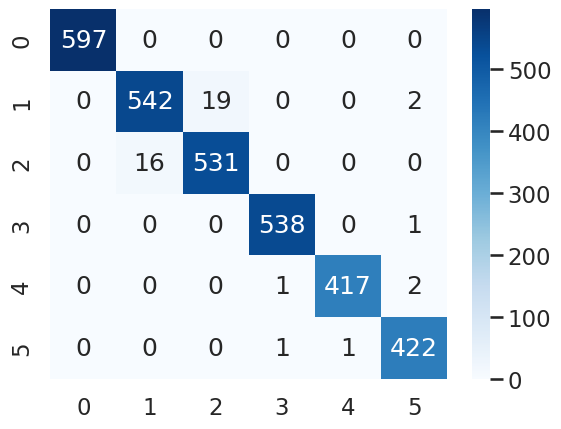

In [17]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues')
plt.show()

<h2 id="Q5">Question 5</h2>

*   Create an AdaBoost model and fit it using grid search, much like question 4. Try a range of estimators between 100 and 200.
*   Compare the errors from AdaBoost to those from the GradientBoostedClassifier.


In [18]:
# from sklearn.ensemble import AdaBoostClassifier
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.model_selection import GridSearchCV, StratifiedKFold

# ABC = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1))

# param_grid = {'n_estimators': [100, 150, 200],
#               'learning_rate': [0.01, 0.001]}

# GV_ABC = GridSearchCV(ABC,
#                       param_grid=param_grid, 
#                       scoring='accuracy',
#                       n_jobs=-1)

# GV_ABC = GV_ABC.fit(X_train, y_train)

In [19]:
import os
import joblib
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

FILENAME = "gv_abc_model.pkl"

if os.path.exists(FILENAME):
    print("Loading cached model...")
    GV_ABC = joblib.load(FILENAME)
else:
    print("Training model...")
    ABC = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1))

    param_grid = {'n_estimators': [100, 150, 200],
                'learning_rate': [0.01, 0.001]}

    GV_ABC = GridSearchCV(ABC,
                        param_grid=param_grid, 
                        scoring='accuracy',
                        n_jobs=-1)

    GV_ABC = GV_ABC.fit(X_train, y_train)

    # Save the model so it can be reloaded next time
    joblib.dump(GV_ABC, FILENAME)
    print("Training completed... Object Saved!")

Loading cached model...


The best model.


In [20]:
# The best model
GV_ABC.best_estimator_

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...r(max_depth=1)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",100
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.01
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None


The error metrics. Note that the issues with class 1 and 2 appear to have become more problematic. Also note other issues for classes 3 - 5. AdaBoost is very sensitive to outliers, so that could be the problem here.


In [21]:
y_pred = GV_ABC.predict(X_test)
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       597
           1       0.00      0.00      0.00       563
           2       0.49      1.00      0.66       547
           3       0.39      1.00      0.56       539
           4       0.00      0.00      0.00       420
           5       0.00      0.00      0.00       424

    accuracy                           0.54      3090
   macro avg       0.31      0.50      0.37      3090
weighted avg       0.35      0.54      0.41      3090



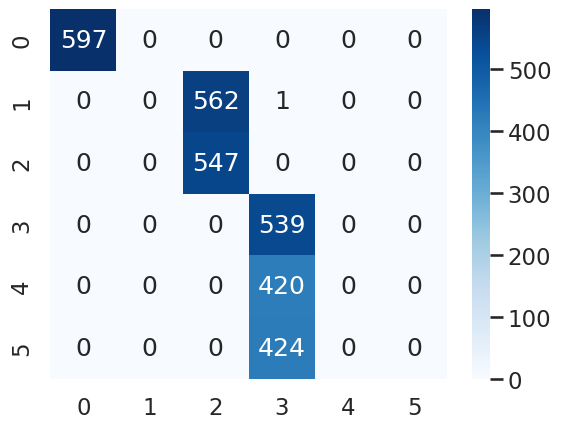

In [22]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues')
plt.show()

This confusion matrix looks strange because our model has completely collapsed and stopped predicting classes 1, 4, and 5 altogether. Instead, it is funneling all those samples into predictions for classes 2 and 3.

This is a classic architectural failure pattern that happens when AdaBoost with Decision Stumps (max_depth=1) meets a complex multiclass problem with a tiny learning rate.

Here is exactly why our model built this specific matrix and how to fix it:

1. **The Anatomy of the Collapse**

    Look at the columns (the model's predictions) in the matrix:
    * **Column 0:** Predicts class 0 perfectly (597 times).
    * **Column 2:** Swallows up almost all of Class 1 (562) and Class 2 (547).
    * **Columns 1, 4, 5:** Completely empty ($0$ predictions across the board).
    
    A decision stump (max_depth=1) can only make a single binary split on one feature at a time. In a multiclass problem with 6 classes (0 through 5), a single stump is mathematically incapable of separating all 6 classes. It can only separate "Class X" from "Everything else."

<BR>

2. **The Twin Culprits: Learning Rate and Estimator Count**

    Because the base trees are so weak, AdaBoost relies on a long sequential chain of updates to slowly build up boundaries for all 6 classes. However, the hyperparameter grid trapped it:
    * **The Learning Rate is too low (0.01 and 0.001):** A learning rate this small means each consecutive tree is only allowed to change the model's overall direction by a microscopic fraction ($1\%$ or $0.1\%$).
    * **Too few estimators (100 to 200):** Combined with that tiny learning rate, 100 or 200 trees aren't nearly enough iterations for the model to "reach" the rarer or more complex classes.The algorithm successfully learned how to separate the easiest group (Class 0), started working on separating classes 2 and 3, and then ran out of gas (iterations) before it could ever start fine-tuning the weights to predict classes 1, 4, and 5.

<BR>


3. **How to Fix It**

    To give AdaBoost enough mathematical flexibility to map all 6 classes, we need to either allow the individual trees to be slightly deeper or drastically increase the learning rate and step count.

<BR>


The Code Fix

Modify the param_grid and the base estimator to let the model actually learn the multiclass structure:

Training model...
Training completed... Object Saved!



              precision    recall  f1-score   support

           0       1.00      1.00      1.00       597
           1       0.96      0.96      0.96       563
           2       0.96      0.95      0.96       547
           3       1.00      0.99      0.99       539
           4       0.99      1.00      0.99       420
           5       0.97      0.99      0.98       424

    accuracy                           0.98      3090
   macro avg       0.98      0.98      0.98      3090
weighted avg       0.98      0.98      0.98      3090






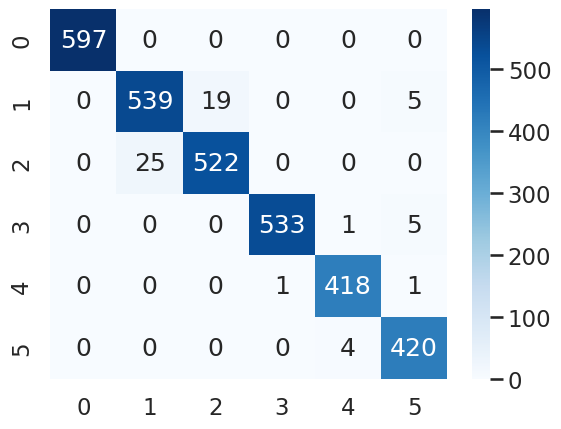

In [23]:
import os
import joblib
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

FILENAME = "gv_abc_model_fix.pkl"

if os.path.exists(FILENAME):
    print("Loading cached model...")
    GV_ABC = joblib.load(FILENAME)
else:
    print("Training model...")

    # 1. Give the base trees a bit more depth (try max_depth=2 or 3 for multiclass)
    ABC = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2))

    # 2. Increase the learning rate so the model can adapt much faster
    param_grid = {
        'n_estimators': [150, 200, 300],
        'learning_rate': [0.1, 0.5, 1.0] # <--- Raised from 0.01/0.001
    }

    GV_ABC = GridSearchCV(ABC,
                        param_grid=param_grid, 
                        scoring='accuracy',
                        n_jobs=-1)

    GV_ABC = GV_ABC.fit(X_train, y_train)

    # Save the model so it can be reloaded next time
    joblib.dump(GV_ABC, FILENAME)
    print("Training completed... Object Saved!")

print("\n\n")
y_pred = GV_ABC.predict(X_test)
print(classification_report(y_test, y_pred, zero_division=0))
print("\n\n")

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues')
plt.show()

<h2 id="Q6">Question 6</h2>

*   Fit a logistic regression model with regularization.
*   Using `VotingClassifier`, fit the logistic regression model along with either the GratientBoostedClassifier or the AdaBoost model (or both) from questions 4 and 5.
*   Determine the error as before and compare the results to the appropriate gradient boosted model(s).
*   Plot the confusion matrix for the best model created in this set of exercises.


In [24]:
from sklearn.linear_model import LogisticRegression

# L2 regularized logistic regression
LR_L2 = LogisticRegression(l1_ratio=0, max_iter=500, solver='saga').fit(X_train, y_train)

Check the errors and confusion matrix for the logistic regression model.


In [25]:
y_pred = LR_L2.predict(X_test)
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       598
           1       0.95      0.96      0.95       558
           2       0.95      0.95      0.95       547
           3       1.00      0.99      0.99       544
           4       0.98      1.00      0.99       413
           5       1.00      0.98      0.99       430

    accuracy                           0.98      3090
   macro avg       0.98      0.98      0.98      3090
weighted avg       0.98      0.98      0.98      3090



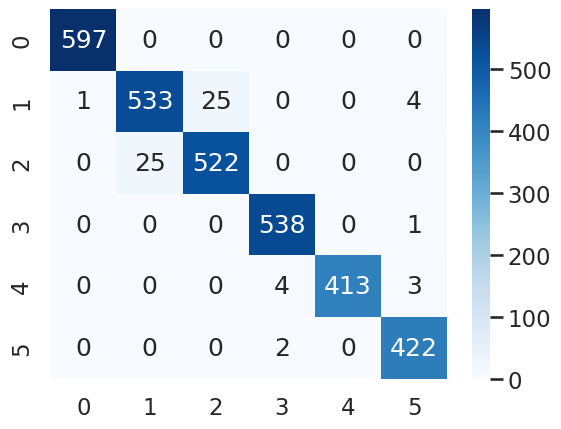

In [26]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues')
plt.show()

And now the stacked model.


In [27]:
# from sklearn.ensemble import VotingClassifier

# # The combined model--logistic regression and gradient boosted trees
# estimators = [('LR_L2', LR_L2), ('GBC', GV_GBC)]

# # Though it wasn't done here, it is often desirable to train 
# # this model using an additional hold-out data set and/or with cross validation
# VC = VotingClassifier(estimators, voting='soft')
# VC = VC.fit(X_train, y_train)

In [28]:
import os
import joblib
from sklearn.ensemble import VotingClassifier

FILENAME = "vc_model.pkl"

if os.path.exists(FILENAME):
    print("Loading cached model...")
    VC = joblib.load(FILENAME)
else:
    print("Training model...")

    # The combined model--logistic regression and gradient boosted trees
    estimators = [('LR_L2', LR_L2), ('GBC', GV_GBC)]
    VC = VotingClassifier(estimators, voting='soft')
    VC = VC.fit(X_train, y_train)

    # Save the model so it can be reloaded next time
    joblib.dump(VC, FILENAME)
    print("Training completed... Object Saved!")

Loading cached model...


Performance for the voting classifier should improve relative to either logistic regression or gradient boosted trees alone. However, the fact that logistic regression does almost as well as gradient boosted trees is an important reminder to try the simplest model first. In some cases, its performance will be good enough.


In [29]:
y_pred = VC.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       597
           1       0.97      0.96      0.97       563
           2       0.97      0.97      0.97       547
           3       1.00      1.00      1.00       539
           4       1.00      0.99      1.00       420
           5       0.98      1.00      0.99       424

    accuracy                           0.99      3090
   macro avg       0.99      0.99      0.99      3090
weighted avg       0.99      0.99      0.99      3090



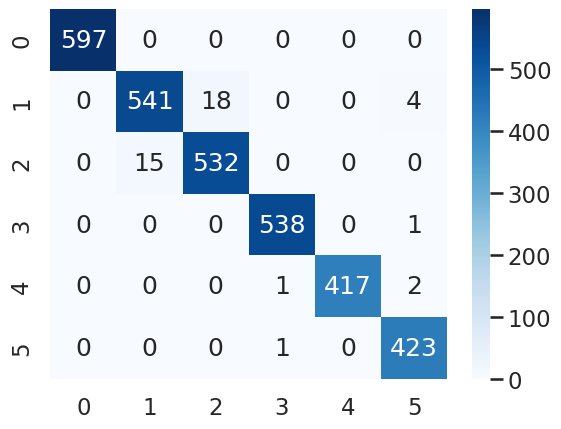

In [30]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues')
plt.show()
#sns.set_context('talk')
#cm = confusion_matrix(y_test, y_pred)
#ax = sns.heatmap(cm, annot=True, fmt='d')


***

### Thank you for completing this lab!

## Author

<a href="https://www.linkedin.com/in/joseph-s-50398b136/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML0101ENSkillsNetwork20718538-2021-01-01" target="_blank">Joseph Santarcangelo</a>

### Other Contributors

<a href="https://www.linkedin.com/in/richard-ye/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML0101ENSkillsNetwork20718538-2021-01-01" target="_blank">Richard Ye</a>

## <h3 align="center"> Machine Learning Foundation (C) 2020 IBM Corporation </h3>

<!--## Change Log

| Date (YYYY-MM-DD) | Version | Changed By | Change Description |
| ----------------- | ------- | ---------- | ------------------ |
| 2022-03-23        | 0.1     | Joseph Santarcangelo | Created Lab Template |
| 2022-05-03        | 0.2     | Richard Ye | Added in estimated time, objectives and table of contents |--!>


